## Loading Libraries

In [7]:
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import plotly.express as px
import folium

from tqdm import tqdm
from pathlib import Path

## Creating Dummy Data

In [15]:
trip_demo = pd.DataFrame({
    "ride_id": list(range(1, 21)),

    "start_station": [
        "Station A", "Station A", "Station A", "Station A", "Station A",
        "Station B", "Station B", "Station B", "Station B",
        "Station C", "Station C", "Station C",
        "Station D", "Station D", "Station D",
        "Station E", "Station E",
        "Station A", "Station B", "Station C"
    ],

    "end_station": [
        "Station B", "Station B", "Station B", "Station C", "Station C",
        "Station A", "Station A", "Station C", "Station D",
        "Station A", "Station B", "Station E",
        "Station A", "Station C", "Station E",
        "Station A", "Station D",
        "Station E", "Station E", "Station D"
    ],

    "started_at": pd.to_datetime([
        "2025-01-01 08:00", "2025-01-01 08:15", "2025-01-01 08:30",
        "2025-01-01 09:00", "2025-01-01 09:20",
        "2025-01-01 10:00", "2025-01-01 10:15", "2025-01-01 10:40",
        "2025-01-01 11:00",
        "2025-01-01 11:30", "2025-01-01 12:00", "2025-01-01 12:20",
        "2025-01-01 13:00", "2025-01-01 13:30", "2025-01-01 14:00",
        "2025-01-01 14:30", "2025-01-01 15:00",
        "2025-01-01 15:30", "2025-01-01 16:00", "2025-01-01 16:30"
    ]),

    "ended_at": pd.to_datetime([
        "2025-01-01 08:10", "2025-01-01 08:28", "2025-01-01 08:42",
        "2025-01-01 09:18", "2025-01-01 09:35",
        "2025-01-01 10:12", "2025-01-01 10:30", "2025-01-01 10:55",
        "2025-01-01 11:18",
        "2025-01-01 11:48", "2025-01-01 12:14", "2025-01-01 12:45",
        "2025-01-01 13:20", "2025-01-01 13:48", "2025-01-01 14:20",
        "2025-01-01 14:55", "2025-01-01 15:22",
        "2025-01-01 15:58", "2025-01-01 16:25", "2025-01-01 16:50"
    ]),

    "member_casual": [
        "member", "member", "casual", "member", "casual",
        "member", "member", "casual", "member",
        "casual", "member", "casual",
        "member", "casual", "member",
        "casual", "member",
        "member", "casual", "member"
    ]
})

trip_demo

,ride_id,start_station,end_station,started_at,ended_at,member_casual
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual
5,6,Station B,Station A,2025-01-01 10:00:00,2025-01-01 10:12:00,member
6,7,Station B,Station A,2025-01-01 10:15:00,2025-01-01 10:30:00,member
7,8,Station B,Station C,2025-01-01 10:40:00,2025-01-01 10:55:00,casual
8,9,Station B,Station D,2025-01-01 11:00:00,2025-01-01 11:18:00,member
9,10,Station C,Station A,2025-01-01 11:30:00,2025-01-01 11:48:00,casual


In [16]:
station_coordinates = pd.DataFrame({
    "station": [
        "Station A",
        "Station B",
        "Station C",
        "Station D",
        "Station E"
    ],
    "lat": [
        40.735,
        40.751,
        40.742,
        40.728,
        40.760
    ],
    "lng": [
        -73.991,
        -73.977,
        -73.985,
        -73.970,
        -73.995
    ]
})

station_coordinates

,station,lat,lng
0,Station A,40.735,-73.991
1,Station B,40.751,-73.977
2,Station C,40.742,-73.985
3,Station D,40.728,-73.970
4,Station E,40.760,-73.995


In [17]:
start_df = trip_demo.merge(station_coordinates,how='left',left_on='start_station',right_on='station')
start_df.rename(columns={
    'lat':'start_lat',
    'lng': 'start_lng'    
}, inplace = True)



In [18]:
end_df = trip_demo.merge(station_coordinates,how='left',left_on='end_station',right_on='station')

end_df.rename(columns={
    'lat':'end_lat',
    'lng': 'end_lng'    
}, inplace = True)

end_df.drop(columns=['station'], inplace=True)
end_df.head()

,ride_id,start_station,end_station,started_at,ended_at,member_casual,end_lat,end_lng
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member,40.751,-73.977
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member,40.751,-73.977
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual,40.751,-73.977
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member,40.742,-73.985
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual,40.742,-73.985


In [19]:

start_cols = ['ride_id', 'start_station','started_at','start_lat', 'start_lng']
end_cols = ['ride_id', 'end_station','ended_at','end_lat', 'end_lng', 'member_casual']

In [20]:
trip_demo = pd.merge(start_df[start_cols], end_df[end_cols],how='inner', on= 'ride_id')
trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual


In [21]:
map_center = [
    pd.concat([trip_demo["start_lat"], trip_demo["end_lat"]]).mean(),
    pd.concat([trip_demo["start_lng"], trip_demo["end_lng"]]).mean()
]

map_center

[np.float64(40.7427), np.float64(-73.9841)]

In [22]:
trip_demo["duration_min"] = (
    trip_demo["ended_at"] - trip_demo["started_at"]
).dt.total_seconds() / 60

trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0


In [23]:
trip_demo["date"] = trip_demo["started_at"].dt.date
trip_demo["hour"] = trip_demo["started_at"].dt.hour
trip_demo["day_name"] = trip_demo["started_at"].dt.day_name()
trip_demo["month_name"] = trip_demo["started_at"].dt.month_name()

trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min,date,hour,day_name,month_name
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0,2025-01-01,8,Wednesday,January
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0,2025-01-01,8,Wednesday,January
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0,2025-01-01,8,Wednesday,January
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0,2025-01-01,9,Wednesday,January
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0,2025-01-01,9,Wednesday,January


## Folium

In [24]:
map_center

[np.float64(40.7427), np.float64(-73.9841)]

In [29]:
m = folium.Map(
    location=map_center,
    zoom_start=13
)
m

In [39]:
for _, row in station_coordinates.iterrows():
    folium.Marker(
        location=[row["lat"], row["lng"]],
        popup=row["station"],
        tooltip = row['station']
    ).add_to(m)

m

In [46]:
# m = folium.Map(
#     location=map_center,
#     zoom_start=13
# )

start_point = [trip_demo.loc[0, "start_lat"], trip_demo.loc[0, "start_lng"]]
end_point = [trip_demo.loc[0, "end_lat"], trip_demo.loc[0, "end_lng"]]

folium.Marker(start_point, popup="Start").add_to(m)
folium.Marker(end_point, popup="End").add_to(m)

folium.PolyLine(
    locations=[start_point, end_point],
    weight=5,
    opacity=0.8
).add_to(m)

m

In [ ]:
import geopandas as gpd
start_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["start_lng"],
        trip_demo["start_lat"]
    ),
    crs="EPSG:4326"
)

end_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["end_lng"],
        trip_demo["end_lat"]
    ),
    crs="EPSG:4326"
)

In [48]:
import geopandas  as gpd

In [49]:
start_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["start_lng"],
        trip_demo["start_lat"]
    ),
    crs="EPSG:4326"
)

<Axes: >

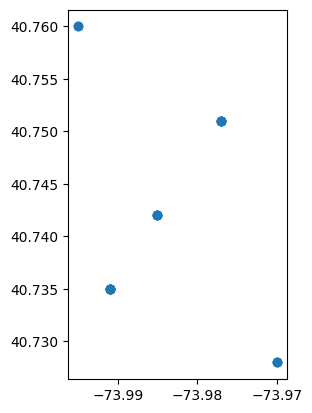

In [50]:
start_points.plot()

<Axes: >

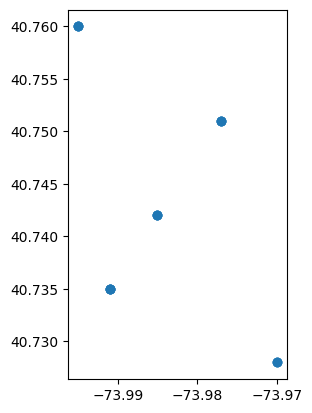

In [53]:
end_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["end_lng"],
        trip_demo["end_lat"]
    ),
    crs="EPSG:4326"
)

end_points.plot()

In [54]:
projected_crs = "EPSG:32618"

start_points_projected = start_points.to_crs(projected_crs)
end_points_projected = end_points.to_crs(projected_crs)

In [58]:
trip_demo["distance_m"] = start_points_projected.geometry.distance(
    end_points_projected.geometry
)

trip_demo["distance_km"] = trip_demo["distance_m"] / 1000


trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min,date,hour,day_name,month_name,distance_m,distance_km
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0,2025-01-01,8,Wednesday,January,2133.621698,2.133622
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0,2025-01-01,8,Wednesday,January,2133.621698,2.133622
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0,2025-01-01,8,Wednesday,January,2133.621698,2.133622
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0,2025-01-01,9,Wednesday,January,927.671157,0.927671
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0,2025-01-01,9,Wednesday,January,927.671157,0.927671


In [59]:
df  = gpd.read_file("../data/citibike/JC/jersey-city-neighborhoods.geojson")

<Axes: >

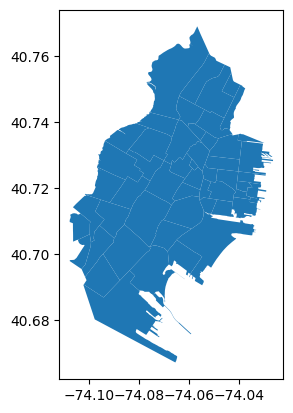

In [60]:
df.plot()

## Jersey

In [3]:
# eval: true
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

### Downloading the Citi Bike Data for `202510`

In [ ]:
CITIBIKE_INDEX_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/test" # ձեզ մոտ թողեց citibike
PERIOD = "202510"

In [62]:
file_name = f"JC-{PERIOD}-citibike-tripdata.zip"
url = f"{CITIBIKE_INDEX_URL}/{file_name}"
url

'https://s3.amazonaws.com/tripdata/JC-202510-citibike-tripdata.zip'

In [ ]:
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True)
zip_path = output_dir / file_name

In [ ]:
print(f"Downloading: {url}")
urlretrieve(url, zip_path)

print(f"Saved ZIP file to: {zip_path}")


with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Extracted files into: {output_dir}")



Downloading: https://s3.amazonaws.com/tripdata/JC-202510-citibike-tripdata.zip
Saved ZIP file to: ../data/test/JC-202510-citibike-tripdata.zip
Extracted files into: ../data/test


### Removing the extracted ZIP file

In [66]:
zip_path.unlink()
print("ZIP file removed.")

ZIP file removed.


In [4]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

CITIBIKE_INDEX_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/citibike" # ձեզ մոտ թողեց citibike


### Function to generate periods in the format YYYYMM

In [7]:
def period_iterator(year:list,start_m:int, stop_m:int)->list:
    """
    year list of strings
    """
    YEAR = year
    MONTH =  [str(i+1) if i+1>9 else "0" + str(i+1) for i in range(start_m, stop_m)]

    periods = []

    for i in YEAR:
        for j in MONTH:
            k = i+j
            periods.append(k)
    # print(periods)
    return periods


In [8]:
PERIODS = period_iterator(["2025"],0,12)
PERIODS

['202501',
 '202502',
 '202503',
 '202504',
 '202505',
 '202506',
 '202507',
 '202508',
 '202509',
 '202510',
 '202511',
 '202512']

### Downlaoding for the Year 2025 and months from 1 to 12

In [ ]:
from pathlib import Path
from zipfile import ZipFile
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

for i in PERIODS:

    try:
        file_name = f"JC-{i}-citibike-tripdata.csv.zip"
        url = f"{CITIBIKE_INDEX_URL}/{file_name}"

        zip_path = output_dir / file_name
        urlretrieve(url, zip_path)

    
    except (HTTPError, URLError, FileNotFoundError):
        file_name = f"JC-{i}-citibike-tripdata.zip"
        url = f"{CITIBIKE_INDEX_URL}/{file_name}"

        zip_path = output_dir / file_name
        urlretrieve(url, zip_path)

    
    
    with ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)
    print(f'{file_name}  Extracted')
    zip_path.unlink()
    print(f"{file_name} removed.")

# Oncee finishd

### Removing `__MACOSX` files

In [11]:
import shutil

shutil.rmtree(output_dir)

### Concatinating all the csv files into one file

In [15]:
import glob
import numpy as np
import pandas as pd

file_names = glob.glob(f'{output_dir}/*.csv')



dfs = []
cols = []
for file_name in file_names:
    df = pd.read_csv(file_name)
    print(df.columns, 2*"||",len(df.columns))

    cols.append(list(df.columns))
    dfs.append(df)

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      d

In [16]:
df =pd.concat(dfs, ignore_index=True)
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002704 entries, 0 to 1002703
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1002704 non-null  str    
 1   rideable_type       1002704 non-null  str    
 2   started_at          1002704 non-null  str    
 3   ended_at            1002704 non-null  str    
 4   start_station_name  1002701 non-null  str    
 5   start_station_id    1002701 non-null  str    
 6   end_station_name    999469 non-null   str    
 7   end_station_id      998307 non-null   str    
 8   start_lat           1002702 non-null  float64
 9   start_lng           1002702 non-null  float64
 10  end_lat             999260 non-null   float64
 11  end_lng             999260 non-null   float64
 12  member_casual       1002704 non-null  str    
dtypes: float64(4), str(9)
memory usage: 222.5 MB


In [19]:
df.to_csv(f"{output_dir}/JC/JC2025.csv", index=False)

### Loading JC 2025 Data

In [8]:
citibike_df = pd.read_csv(f"{output_dir}/JC/JC2025.csv", 
                          parse_dates=['started_at','ended_at'])

In [9]:
citibike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002704 entries, 0 to 1002703
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             1002704 non-null  str           
 1   rideable_type       1002704 non-null  str           
 2   started_at          1002704 non-null  datetime64[us]
 3   ended_at            1002704 non-null  datetime64[us]
 4   start_station_name  1002701 non-null  str           
 5   start_station_id    1002701 non-null  str           
 6   end_station_name    999469 non-null   str           
 7   end_station_id      998307 non-null   str           
 8   start_lat           1002702 non-null  float64       
 9   start_lng           1002702 non-null  float64       
 10  end_lat             999260 non-null   float64       
 11  end_lng             999260 non-null   float64       
 12  member_casual       1002704 non-null  str           
dtypes: datetime64[us](2), f

### Missing Values

In [10]:
# option 1:

citibike_df.shape[0]

# option 2:
len(citibike_df)

1002704

In [11]:
missing_values = citibike_df.isnull().sum().reset_index()

missing_values.columns = ['column_name', 'missing_count']

missing_values["missing_percentage"] = (missing_values["missing_count"] / len(citibike_df)) * 100

missing_values.sort_values(by="missing_percentage", ascending=False, inplace=True)

missing_values

,column_name,missing_count,missing_percentage
7,end_station_id,4397,0.438514
10,end_lat,3444,0.343471
11,end_lng,3444,0.343471
6,end_station_name,3235,0.322628
4,start_station_name,3,0.000299
5,start_station_id,3,0.000299
8,start_lat,2,0.000199
9,start_lng,2,0.000199
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


### Data Enrichment

In [13]:
citibike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002704 entries, 0 to 1002703
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             1002704 non-null  str           
 1   rideable_type       1002704 non-null  str           
 2   started_at          1002704 non-null  datetime64[us]
 3   ended_at            1002704 non-null  datetime64[us]
 4   start_station_name  1002701 non-null  str           
 5   start_station_id    1002701 non-null  str           
 6   end_station_name    999469 non-null   str           
 7   end_station_id      998307 non-null   str           
 8   start_lat           1002702 non-null  float64       
 9   start_lng           1002702 non-null  float64       
 10  end_lat             999260 non-null   float64       
 11  end_lng             999260 non-null   float64       
 12  member_casual       1002704 non-null  str           
dtypes: datetime64[us](2), f

#### Duration

In [14]:
citibike_df['ride_duration_min'] = (citibike_df["ended_at"] - citibike_df["started_at"]).dt.total_seconds()/60

In [15]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_min
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383


In [16]:
citibike_df.shape

(1002704, 14)

In [18]:
citibike_df = citibike_df[
    (citibike_df['ride_duration_min']>1) & (citibike_df['ride_duration_min']<24*60)
]

citibike_df.shape


(1002333, 14)

In [19]:
missing_values = citibike_df.isnull().sum().reset_index()

missing_values.columns = ['column_name', 'missing_count']

missing_values["missing_percentage"] = (missing_values["missing_count"] / len(citibike_df)) * 100

missing_values.sort_values(by="missing_percentage", ascending=False, inplace=True)

missing_values

,column_name,missing_count,missing_percentage
7,end_station_id,4049,0.403958
10,end_lat,3106,0.309877
11,end_lng,3106,0.309877
6,end_station_name,2887,0.288028
4,start_station_name,3,0.000299
5,start_station_id,3,0.000299
8,start_lat,2,0.000200
9,start_lng,2,0.000200
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


#### Droping Missing Values

In [21]:
citibike_df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'ride_duration_min'],
      dtype='str')

In [ ]:
['ride_id', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
        ]

In [ ]:
citibike_df = citibike_df.dropna(
    subset=['ride_id', 'started_at', 'ended_at','start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
        ]
)

In [25]:
missing_values = citibike_df.isnull().sum().reset_index()

missing_values.columns = ['column_name', 'missing_count']

missing_values["missing_percentage"] = (missing_values["missing_count"] / len(citibike_df)) * 100

missing_values.sort_values(by="missing_percentage", ascending=False, inplace=True)

missing_values

,column_name,missing_count,missing_percentage
0,ride_id,0,0.0
1,rideable_type,0,0.0
2,started_at,0,0.0
3,ended_at,0,0.0
4,start_station_name,0,0.0
5,start_station_id,0,0.0
6,end_station_name,0,0.0
7,end_station_id,0,0.0
8,start_lat,0,0.0
9,start_lng,0,0.0


#### Adding time granularity

In [69]:
citibike_df['date'] = citibike_df['started_at'].dt.date
citibike_df['month'] = citibike_df['started_at'].dt.to_period('M').astype(str)
citibike_df['month_name'] = citibike_df['started_at'].dt.month_name()
citibike_df['month_number'] = citibike_df['started_at'].dt.month
citibike_df['day_of_week'] = citibike_df['started_at'].dt.day_name()
citibike_df['hour'] = citibike_df['started_at'].dt.hour

In [34]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_min,date,month,day_of_week,hour,month_name,month_number
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,Tuesday,18,November,11
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,Wednesday,16,November,11
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,Tuesday,22,November,11
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,Saturday,6,November,11
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,Monday,20,November,11


In [32]:
def assign_season(month_number):
    if month_number in [12,1,2]:
        return 'Winter'
    elif month_number in [3,4,5]:
        return 'Spring'
    elif month_number in [6,7,8]:
        return 'Summer'
    else:
        return 'Autumn'

In [35]:
citibike_df['season'] = citibike_df['month_number'].apply(assign_season)

citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,ride_duration_min,date,month,day_of_week,hour,month_name,month_number,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,13.307467,2025-11-18,2025-11,Tuesday,18,November,11,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,14.495367,2025-11-26,2025-11,Wednesday,16,November,11,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,...,-74.042521,member,6.983450,2025-11-04,2025-11,Tuesday,22,November,11,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,5.803383,2025-11-08,2025-11,Saturday,6,November,11,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,6.658383,2025-11-24,2025-11,Monday,20,November,11,Autumn


#### Storing Enriched Data 

In [36]:
citibike_df.to_csv(f'{output_dir}/JC/JC2025_Enriched.csv',index=False)

### Getting Weather

In [37]:

import requests

lat = 40.7178
lng = -74.0431

start_date = "2025-01-01"
end_date = "2025-12-31"

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lng,
    "start_date": start_date,
    "end_date": end_date,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "wind_speed_10m_max"
    ],
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
response.raise_for_status()

In [42]:
data = response.json()

In [44]:
data['daily'].keys()

dict_keys(['time', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max'])

In [45]:
weather_data = pd.DataFrame(data['daily'])
weather_data.head()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,10.9,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.3,-3.6,-2.2,0.0,0.0,0.0,19.9


In [47]:
weather_data.rename(columns={'time':'date'},inplace=True)
weather_data.to_csv(f'{output_dir}/JC/jersey_weather_2025.csv',index=False)

In [50]:
weather_daily = pd.read_csv(f'{output_dir}/JC/jersey_weather_2025.csv', parse_dates=['date'])
weather_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 365 non-null    datetime64[us]
 1   temperature_2m_max   365 non-null    float64       
 2   temperature_2m_min   365 non-null    float64       
 3   temperature_2m_mean  365 non-null    float64       
 4   precipitation_sum    365 non-null    float64       
 5   rain_sum             365 non-null    float64       
 6   snowfall_sum         365 non-null    float64       
 7   wind_speed_10m_max   365 non-null    float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 22.9 KB


In [51]:
weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,10.9,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.3,-3.6,-2.2,0.0,0.0,0.0,19.9


In [56]:
weather_daily = pd.read_csv(f'{output_dir}/JC/jersey_weather_2025.csv', parse_dates=['date'])
weather_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 365 non-null    datetime64[us]
 1   temperature_2m_max   365 non-null    float64       
 2   temperature_2m_min   365 non-null    float64       
 3   temperature_2m_mean  365 non-null    float64       
 4   precipitation_sum    365 non-null    float64       
 5   rain_sum             365 non-null    float64       
 6   snowfall_sum         365 non-null    float64       
 7   wind_speed_10m_max   365 non-null    float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 22.9 KB


In [57]:
### 
fig = px.line(
    weather_daily,
    x="date",
    y="temperature_2m_mean",
    title="Daily Average Temperature Over Time",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average Temperature",
    hovermode="x unified"
)

fig.show()

In [ ]:
### wide format
weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,10.9,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.3,-3.6,-2.2,0.0,0.0,0.0,19.9


In [ ]:
# date, temperature, type գունավորի

In [60]:
temperature_long = weather_daily.melt(
    id_vars = 'date',
    value_vars = [
        'temperature_2m_max',	'temperature_2m_min',	'temperature_2m_mean'
    ],

    var_name = 'temperature_type',
    value_name = 'temperature'
)

temperature_long.head()

,date,temperature_type,temperature
0,2025-01-01,temperature_2m_max,10.9
1,2025-01-02,temperature_2m_max,5.4
2,2025-01-03,temperature_2m_max,3.2
3,2025-01-04,temperature_2m_max,-0.1
4,2025-01-05,temperature_2m_max,0.3


### Homework Part 1

1. փորձեք ջնջել `tempreture_` բառը `temerature_type` սյան միջից
2. քամին և տեղումները

In [62]:
### 
fig = px.line(
    temperature_long,
    x="date",
    y="temperature",
    color = 'temperature_type',
    title="Daily Temperature Over Time: Min, Max, Mean",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average Temperature",
    hovermode="x unified"
)

fig.show()

In [63]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,ride_duration_min,date,month,day_of_week,hour,month_name,month_number,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,13.307467,2025-11-18,2025-11,Tuesday,18,November,11,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,14.495367,2025-11-26,2025-11,Wednesday,16,November,11,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,...,-74.042521,member,6.983450,2025-11-04,2025-11,Tuesday,22,November,11,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,5.803383,2025-11-08,2025-11,Saturday,6,November,11,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,6.658383,2025-11-24,2025-11,Monday,20,November,11,Autumn


### Monthly Rides

In [64]:
citibike_df.info()

<class 'pandas.DataFrame'>
Index: 998281 entries, 0 to 1002703
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             998281 non-null  str           
 1   rideable_type       998281 non-null  str           
 2   started_at          998281 non-null  datetime64[us]
 3   ended_at            998281 non-null  datetime64[us]
 4   start_station_name  998281 non-null  str           
 5   start_station_id    998281 non-null  str           
 6   end_station_name    998281 non-null  str           
 7   end_station_id      998281 non-null  str           
 8   start_lat           998281 non-null  float64       
 9   start_lng           998281 non-null  float64       
 10  end_lat             998281 non-null  float64       
 11  end_lng             998281 non-null  float64       
 12  member_casual       998281 non-null  str           
 13  ride_duration_min   998281 non-null  float64

In [71]:
monthly_rides = (citibike_df
                 .groupby('month',as_index=False)
                 .agg(number_of_rides = ('ride_id',"count"))
                 )
monthly_rides

,month,number_of_rides
0,2024-12,2
1,2025-01,50477
2,2025-02,45131
3,2025-03,73124
4,2025-04,81295
5,2025-05,92880
6,2025-06,96736
7,2025-07,107374
8,2025-08,108001
9,2025-09,115580


In [72]:
fig = px.bar(
    monthly_rides,
    x="month",
    y="number_of_rides",
    title="Number of Citi Bike Rides per Month"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Number of Rides",
)

fig.show()

In [73]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,ride_duration_min,date,month,day_of_week,hour,month_name,month_number,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,13.307467,2025-11-18,2025-11,Tuesday,18,November,11,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,14.495367,2025-11-26,2025-11,Wednesday,16,November,11,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,...,-74.042521,member,6.983450,2025-11-04,2025-11,Tuesday,22,November,11,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,5.803383,2025-11-08,2025-11,Saturday,6,November,11,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,6.658383,2025-11-24,2025-11,Monday,20,November,11,Autumn



### Homework Part 2

**Try to visualize:**

- Day_of_week
  - Highlight the highest and lowest days ()
- Seasons
- Hourly
    - Morning
    - Daytime
    - Eveninng
    


### Top Start Stations

In [75]:
top_stations = (citibike_df
                .groupby('start_station_name', as_index=False)
                .agg(number_of_departures= ('ride_id','count') )
                .sort_values("number_of_departures",ascending=False)
                .head(10))

top_stations

,start_station_name,number_of_departures
52,Grove St PATH,44984
58,Hoboken Terminal - Hudson St & Hudson Pl,25879
53,Hamilton Park,22232
95,River St & Newark St,21383
86,Newport PATH,20641
18,Bergen Ave & Sip Ave,20370
44,Exchange Pl,19982
0,11 St & Washington St,19469
94,River St & 1 St,19125
87,Newport Pkwy,18709


### Top End Stations 

In [86]:
N = 15
top_stations = (citibike_df
                .groupby('end_station_name', as_index=False)
                .agg(number_of_arrivals = ('ride_id','count') )
                .sort_values("number_of_arrivals",ascending=False)
                .head(N))

top_stations

,end_station_name,number_of_arrivals
232,Grove St PATH,47744
241,Hoboken Terminal - Hudson St & Hudson Pl,26638
233,Hamilton Park,22347
347,River St & Newark St,22113
317,Newport PATH,20698
73,Bergen Ave & Sip Ave,20357
207,Exchange Pl,20142
7,11 St & Washington St,19501
318,Newport Pkwy,18704
346,River St & 1 St,18515


In [88]:
fig = px.bar(
    data_frame=top_stations,
    x = 'number_of_arrivals',
    y = 'end_station_name',
    orientation = 'h',
    title=f"Top {N} Stations by Number of Departures",
    text_auto= True

)
fig.update_layout(
    xaxis_title="Number of Arrivals",
    yaxis_title="End Station"
)


fig.show()

In [89]:
# փորձեք միացնել ստարտը և էնդը մի թեյբլի մեջ ու մեկ փոփոխությամբ փոխեք վիզուալիցացիան

### Merging with weather Data

In [96]:
daily_rides = (citibike_df
               .groupby('date', as_index=False)
               .agg(number_of_daily_rides = ('ride_id','count'))
               )


daily_rides['date'] = pd.to_datetime(daily_rides['date'])
daily_rides.head()

,date,number_of_daily_rides
0,2024-12-31,2
1,2025-01-01,1174
2,2025-01-02,1709
3,2025-01-03,1764
4,2025-01-04,1336


In [98]:
bike_weather_daily = daily_rides.merge(weather_daily,
                                       on='date',
                                       how = 'left')

bike_weather_daily.head()

,date,number_of_daily_rides,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2024-12-31,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,1174,10.9,3.9,7.4,4.5,4.5,0.0,23.2
2,2025-01-02,1709,5.4,0.3,2.6,0.0,0.0,0.0,25.1
3,2025-01-03,1764,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
4,2025-01-04,1336,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1


#### Rides vs Average Temperature

In [105]:
fig = px.scatter(
    data_frame = bike_weather_daily,
    x = 'temperature_2m_mean',
    y = 'number_of_daily_rides',
    trendline = 'ols',
    title="Daily Rides vs Average Temperature"
)

fig.update_layout(
    xaxis_title="Average Daily Temperature",
    yaxis_title="Number of Rides"
)

fig.show()

In [106]:
fig = px.scatter(
    data_frame = bike_weather_daily,
    x = 'wind_speed_10m_max',
    y = 'number_of_daily_rides',
    trendline = 'ols',
    title="Daily Rides vs Wind Spead"
)

fig.update_layout(
    xaxis_title="Wind Spead",
    yaxis_title="Number of Rides"
)

fig.show()

In [ ]:
fig = px.scatter(
    data_frame = bike_weather_daily,
    x = 'wind_speed_10m_max',
    y = 'number_of_daily_rides',
    trendline = 'ols',
    title="Daily Rides vs Wind Spead"
)

fig.update_layout(
    xaxis_title="Wind Spead",
    yaxis_title="Number of Rides"
)

fig.show()

## Dual Axis

In [108]:
bike_weather_daily.head()

,date,number_of_daily_rides,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2024-12-31,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,1174,10.9,3.9,7.4,4.5,4.5,0.0,23.2
2,2025-01-02,1709,5.4,0.3,2.6,0.0,0.0,0.0,25.1
3,2025-01-03,1764,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
4,2025-01-04,1336,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1


In [115]:
import plotly.graph_objects as go


fig = go.Figure()


fig.add_trace(
    go.Scatter(
        x = bike_weather_daily['date'],
        y = bike_weather_daily['number_of_daily_rides'],
        mode = 'lines',
        name = 'Daily Rides',
        yaxis = 'y1' 
    )
)

fig.add_trace(
    go.Scatter(
        x = bike_weather_daily['date'],
        y = bike_weather_daily['temperature_2m_mean'],
        mode = 'lines',
        name = 'Daily Average Temperature',
        yaxis = 'y2' 
    )
)

fig.update_layout(
    title = '',
    xaxis = dict(title = 'Day'),
    yaxis = dict(title = 'Daily Rides', side = 'left'),
    yaxis2 = dict(title = 'Temperature', side = 'right', overlaying = 'y'),
    hovermode = 'x unified'


)


fig.show()